# 01 · Cross-validation diagnosis
`StratifiedKFold(shuffle)` leaks because the 39/40-overlapping windows of one job are near-duplicates scattered across folds. We compare what each CV **believes** (CV-AP) with the **truth** (temporal test PR-AUC).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve().parents[1]  # notebooks/ -> 02_cv_strategies/
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd
from IPython.display import HTML, display
from cv_strategies import config as C, evaluation_ext as E, report as R
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('session folder:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


In [2]:
cv = pd.read_csv(C.CV_COMPARISON_CSV)
cv['inflation_x'] = cv['cv_ap_mean']/cv['test_pr_auc']
cv[['strategy','n_splits','cv_ap_mean','test_pr_auc','inflation_x']]

,strategy,n_splits,cv_ap_mean,test_pr_auc,inflation_x
0,stratified,3,0.4627,0.0808,5.7278
1,group,3,0.2153,0.0808,2.6653
2,stratified_group,3,0.2160,0.0775,2.7878
3,tscv,5,0.0880,0.0808,1.0892
4,purged,5,0.1198,0.0808,1.4833
5,logo_weekly,9,0.1361,0.0775,1.7570



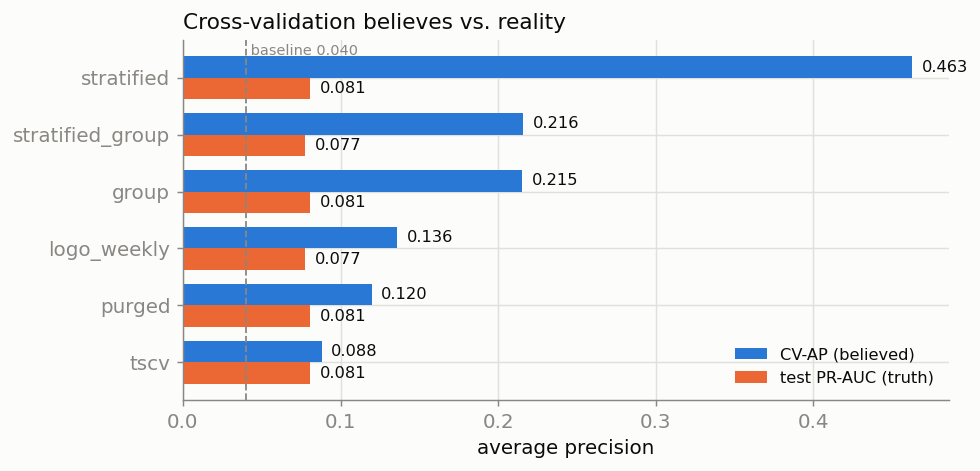

In [3]:
display(HTML(f'<img src="{R.fig_cv_diagnosis(cv, E.baseline())}">'))

### The splitters keep whole jobs together — a cheap structural check
No model fitting: just verify fold membership on the train split.

In [4]:
from cv_strategies import cv as CV
a = C.load_frozen(mmap=True); y=np.asarray(a['y_train']); g=np.asarray(a['job_ids_train'])
tt,_ = C.load_win_time()
for name in ['stratified','group','purged','tscv','logo_weekly']:
    sp = CV.make_splits(name, y=y, groups=g, times=tt)
    shared = max(len(set(g[tr]) & set(g[te])) for tr,te in sp)
    print(f'{name:<14} folds={len(sp):<2} jobs shared between any train/val fold: {shared}')

stratified     folds=3  jobs shared between any train/val fold: 10244


group          folds=3  jobs shared between any train/val fold: 0


purged         folds=5  jobs shared between any train/val fold: 0


tscv           folds=5  jobs shared between any train/val fold: 112


logo_weekly    folds=9  jobs shared between any train/val fold: 0


**Takeaway.** Leaky `stratified` overstates AP ~5.7×; **grouping** halves it but is still ~2.7×; only **temporal** CV (`tscv` ~1.1×, `purged` ~1.5×) tracks the truth. Grouping is necessary but not sufficient.